In [89]:
import os, numpy as np, cv2, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv2D, DepthwiseConv2D, BatchNormalization,
    ReLU, GlobalAveragePooling2D, Dense, Dropout, Add)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight

print("TF:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)


TF: 2.19.0


In [90]:
DATASET_PATH = "/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"
CLASSES   = ["benign", "malignant", "normal"]
IMG_SIZE  = 128      # smaller → less overfitting, faster convergence
BATCH     = 8        # small batch → more gradient updates per epoch, better generalisation
EPOCHS    = 50
SEED      = 42


## 1. Load & Verify Dataset

In [91]:
images, labels = [], []

for cls in CLASSES:
    cls_path = os.path.join(DATASET_PATH, cls)
    count = 0
    for fname in sorted(os.listdir(cls_path)):
        if "_mask" in fname:
            continue
        img = cv2.imread(os.path.join(cls_path, fname))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32) / 255.0
        images.append(img)
        labels.append(cls)
        count += 1
    print(f"  {cls}: {count} images loaded")

X = np.array(images)
y = np.array(labels)
print(f"\nTotal: {X.shape}, dtype={X.dtype}, min={X.min():.2f}, max={X.max():.2f}")


  benign: 437 images loaded
  malignant: 210 images loaded
  normal: 133 images loaded

Total: (780, 128, 128, 3), dtype=float32, min=0.00, max=1.00


## 2. Split (70 / 15 / 15) Stratified

In [92]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Label map:", dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y_enc, test_size=0.30, stratify=y_enc, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

print(f"Train: {X_train.shape}  →  {np.bincount(y_train)}")
print(f"Val  : {X_val.shape}    →  {np.bincount(y_val)}")
print(f"Test : {X_test.shape}   →  {np.bincount(y_test)}")


Label map: {np.str_('benign'): np.int64(0), np.str_('malignant'): np.int64(1), np.str_('normal'): np.int64(2)}
Train: (546, 128, 128, 3)  →  [306 147  93]
Val  : (117, 128, 128, 3)    →  [65 32 20]
Test : (117, 128, 128, 3)   →  [66 31 20]


## 3. Manual Augmentation (applied at training time)

In [93]:
def augment_batch(images, labels):
    """
    Apply random augmentation to a numpy batch.
    Avoids ImageDataGenerator flow() step_count mismatch issues.
    """
    aug_imgs, aug_lbs = [], []
    for img, lb in zip(images, labels):
        # Random horizontal flip
        if np.random.rand() > 0.5:
            img = np.fliplr(img)
        # Random brightness ±20%
        factor = 1.0 + np.random.uniform(-0.2, 0.2)
        img = np.clip(img * factor, 0, 1)
        # Random rotation ±15 deg
        angle = np.random.uniform(-15, 15)
        M = cv2.getRotationMatrix2D((IMG_SIZE//2, IMG_SIZE//2), angle, 1.0)
        img = cv2.warpAffine(img, M, (IMG_SIZE, IMG_SIZE))
        aug_imgs.append(img)
        aug_lbs.append(lb)
    return np.array(aug_imgs, dtype=np.float32), np.array(aug_lbs)


def data_generator(X, y, batch_size, class_weights, augment=True, shuffle=True):
    idx = np.arange(len(X))
    while True:
        if shuffle:
            np.random.shuffle(idx)
        for start in range(0, len(idx), batch_size):
            batch_idx = idx[start:start+batch_size]
            bx, by = X[batch_idx], y[batch_idx]
            if augment:
                bx, by = augment_batch(bx, by)
            # Convert class_weights to per-sample weight array
            sw = np.array([class_weights[label] for label in by], dtype=np.float32)
            yield bx, by, sw


## 4. Depthwise + Pointwise Block & Model

Key fix: **3 blocks only, max 128 filters, L2 reg, correct LR schedule**

In [94]:
def dw_pw_block(x, filters, strides=(1,1)):
    """
    Depthwise Conv  →  per-channel spatial features (3×3)
    Pointwise Conv  →  cross-channel mixing       (1×1)
    """
    x = DepthwiseConv2D((3,3), strides=strides, padding='same',
                        use_bias=False,
                        depthwise_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(filters, (1,1), padding='same',
               use_bias=False,
               kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    return x


def build_model():
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Stem
    x = Conv2D(16, (3,3), strides=(2,2), padding='same',
               use_bias=False, kernel_regularizer=l2(1e-4))(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # 3 DW+PW blocks — deliberately small for ~780 sample dataset
    x = dw_pw_block(x, 32)
    x = dw_pw_block(x, 64, strides=(2,2))
    x = dw_pw_block(x, 128, strides=(2,2))

    # Global pooling + head
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-3))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(3, activation='softmax')(x)

    model = Model(inputs, outputs, name='BUSI_DW_PW')

    # Cosine decay LR — warms up then decays smoothly over 50 epochs
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=5e-3,
        decay_steps=50 * (len(X_train) // BATCH),
        alpha=1e-5
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr_schedule),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tf.keras.backend.clear_session()
model = build_model()
model.summary()
print(f"\nTotal params: {model.count_params():,}  ← intentionally small")


Model: "BUSI_DW_PW"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 64, 64, 16)     │           144 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 32, 32, 32)     │           288 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_2              │ (None, 16, 16, 64)     │           576 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 22,051 (86.14 KB)

 Trainable params: 21,347 (83.39 KB)

 Non-trainable params: 704 (2.75 KB)


Total params: 22,051  ← intentionally small


## 5. Class Weights

In [95]:
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))
print("Class weights:", {le.classes_[k]: round(v,3) for k,v in class_weights.items()})


Class weights: {np.str_('benign'): np.float64(0.595), np.str_('malignant'): np.float64(1.238), np.str_('normal'): np.float64(1.957)}


## 6. Train for Full 50 Epochs

In [96]:
from tensorflow.keras.callbacks import ModelCheckpoint

steps = max(1, len(X_train) // BATCH)
print(f"Steps per epoch: {steps}")

checkpoint = ModelCheckpoint(
    'best_busi.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=0
)

ttrain_gen = data_generator(X_train, y_train, BATCH, class_weights, augment=True)

history = model.fit(
    train_gen,
    steps_per_epoch=steps,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    # class_weight removed — handled inside generator as sample_weight
    callbacks=[checkpoint],
    verbose=1
)
# Load best weights for evaluation
model.load_weights('best_busi.weights.h5')
print(f"\nBest val_accuracy: {max(history.history['val_accuracy']):.4f} at epoch ",
      np.argmax(history.history['val_accuracy'])+1)


Steps per epoch: 68
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 227ms/step - accuracy: 0.5210 - loss: 1.1191 - val_accuracy: 0.5556 - val_loss: 1.1231
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5583 - loss: 1.0168 - val_accuracy: 0.5556 - val_loss: 1.0950
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5590 - loss: 1.0062 - val_accuracy: 0.2735 - val_loss: 1.0994
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5709 - loss: 0.9532 - val_accuracy: 0.2735 - val_loss: 1.1261
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6259 - loss: 0.9551 - val_accuracy: 0.2735 - val_loss: 1.2456
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6335 - loss: 0.9550 - val_accuracy: 0.5641 - val_loss: 0.9943
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5943 - loss: 0.9794 - val_accuracy: 0.5556 - val_loss: 2.3774
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6057 - loss: 0.9263 - val_accur

## 7. Training Curves

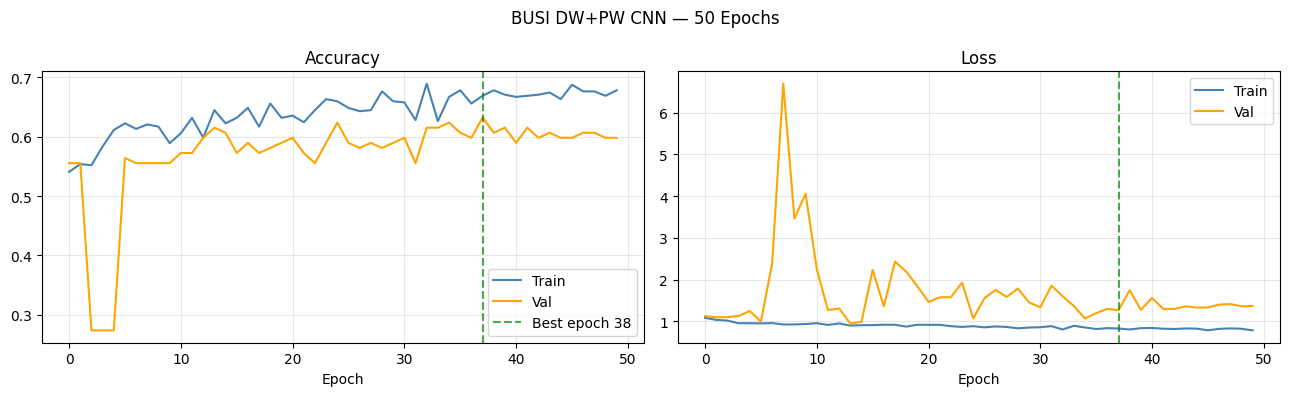

In [97]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
best_ep = np.argmax(history.history['val_accuracy'])

ax1.plot(history.history['accuracy'],     label='Train', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Val',   color='orange')
ax1.axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best epoch {best_ep+1}')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=.3)

ax2.plot(history.history['loss'],     label='Train', color='steelblue')
ax2.plot(history.history['val_loss'], label='Val',   color='orange')
ax2.axvline(best_ep, color='green', linestyle='--', alpha=0.7)
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=.3)

plt.suptitle('BUSI DW+PW CNN — 50 Epochs', fontsize=12)
plt.tight_layout(); plt.show()


## 8. Evaluate on Test Set

In [98]:
y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
names  = le.classes_

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("="*45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("="*45)
print()
print(classification_report(y_test, y_pred, target_names=names, zero_division=0))

# Sanity check — how many unique classes predicted?
unique_preds = np.unique(y_pred)
print(f"Unique classes predicted: {[names[i] for i in unique_preds]}")


  Accuracy  : 0.6410
  Precision : 0.5316
  Recall    : 0.6410
  F1 Score  : 0.5766

              precision    recall  f1-score   support

      benign       0.64      0.86      0.74        66
   malignant       0.64      0.58      0.61        31
      normal       0.00      0.00      0.00        20

    accuracy                           0.64       117
   macro avg       0.43      0.48      0.45       117
weighted avg       0.53      0.64      0.58       117

Unique classes predicted: [np.str_('benign'), np.str_('malignant')]


## 9. Confusion Matrix

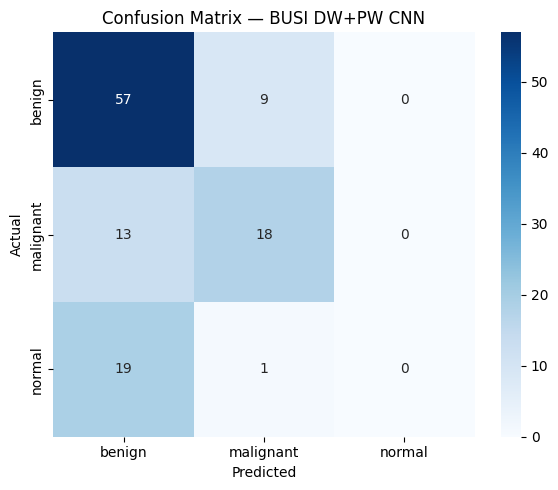

In [99]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=names, yticklabels=names)
plt.title('Confusion Matrix — BUSI DW+PW CNN')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()


## 10. Per-Class Confidence (Prediction Distribution)

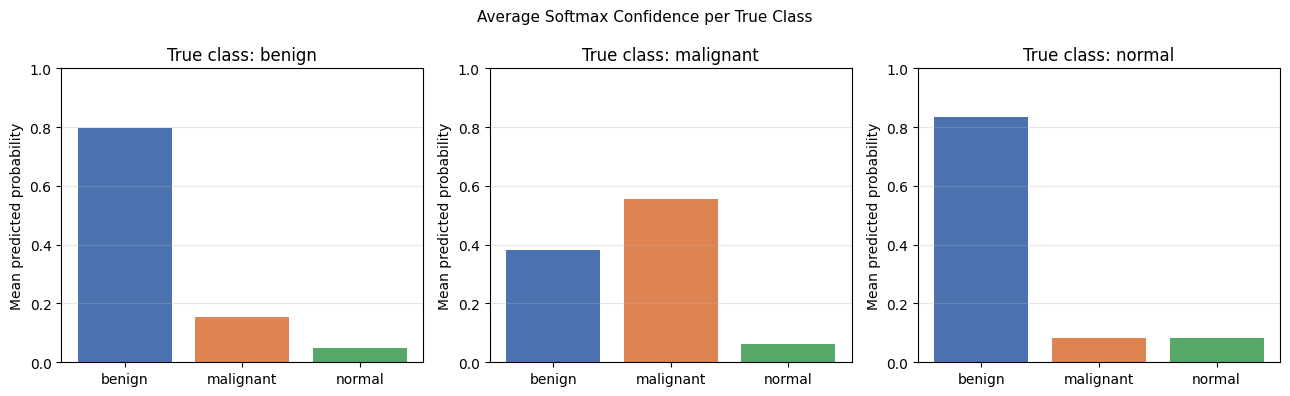

In [100]:
# Shows what the model actually thinks — useful for diagnosing class collapse
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, cls in enumerate(names):
    mask = y_test == i
    if mask.sum() == 0:
        continue
    probs = y_prob[mask]
    axes[i].bar(names, probs.mean(axis=0), color=['#4C72B0','#DD8452','#55A868'])
    axes[i].set_title(f"True class: {cls}")
    axes[i].set_ylabel('Mean predicted probability')
    axes[i].set_ylim(0, 1)
    axes[i].grid(axis='y', alpha=0.3)
plt.suptitle('Average Softmax Confidence per True Class', fontsize=11)
plt.tight_layout(); plt.show()


## 11. Sample Predictions

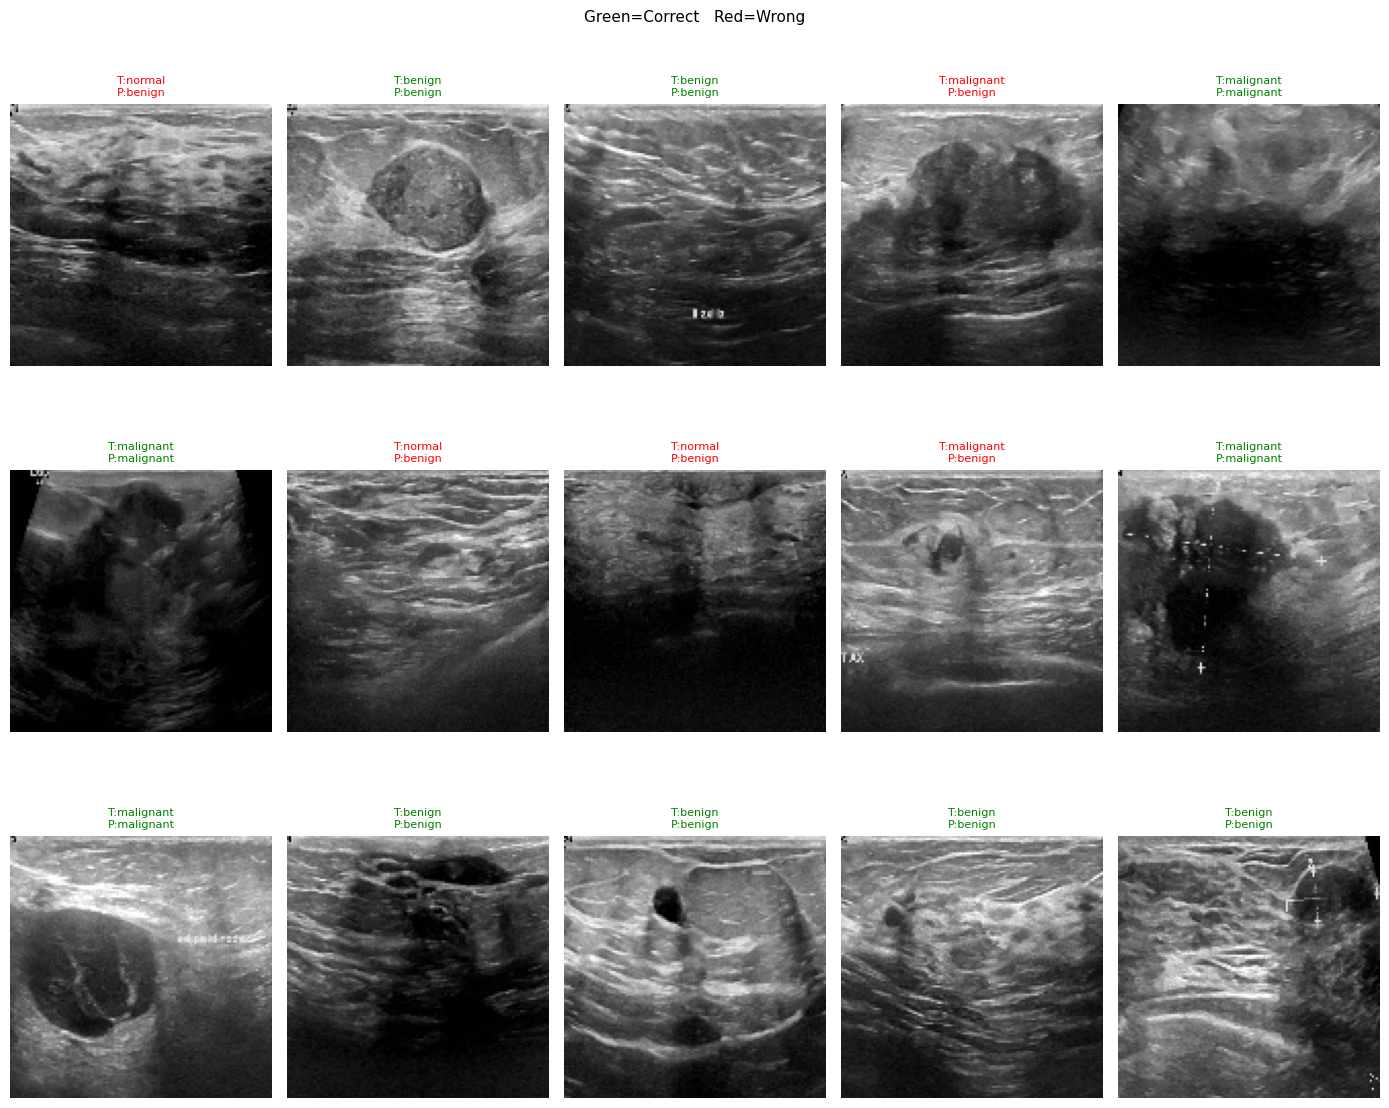

In [101]:
idx  = np.random.choice(len(X_test), 15, replace=False)
imgs = X_test[idx]
prob = model.predict(imgs, verbose=0)
pred = np.argmax(prob, axis=1)
true = y_test[idx]

plt.figure(figsize=(14, 12))
for i in range(15):
    ax = plt.subplot(3, 5, i+1); ax.axis('off')
    col = 'green' if pred[i]==true[i] else 'red'
    ax.set_title(f"T:{names[true[i]]}\nP:{names[pred[i]]}", color=col, fontsize=8)
    plt.imshow(imgs[i])
plt.suptitle('Green=Correct   Red=Wrong', fontsize=11)
plt.tight_layout(); plt.show()


## 12. Save

In [102]:
model.save("busi_dw_pw_final.h5")
print("Saved: busi_dw_pw_final.h5")


Saved: busi_dw_pw_final.h5
